# Introduction to Image Processing in Python

Juan Diego Perez Navarro  
T00067699  
Universidad Tecnológica de Bolívar


In [2]:
import numpy as np

import cv2
from skimage import io
from PIL import Image

import seaborn as sns
import matplotlib.pyplot as plt

## TODO #1: Read an image from a URL, modify it and display it

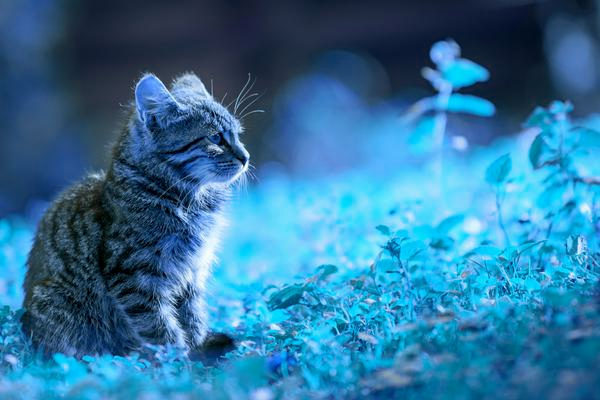

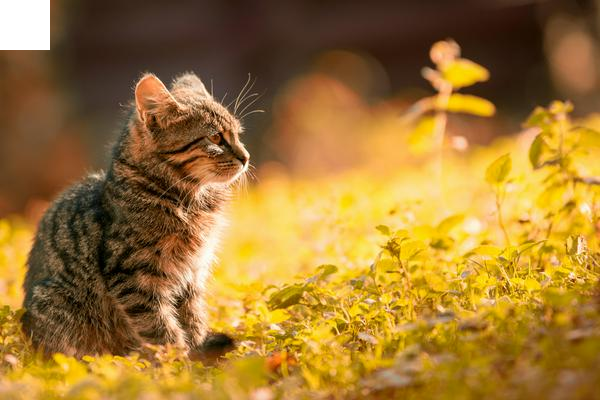

In [67]:
url = "https://placekittens.com/600/400"
my_img = io.imread(url)

display(Image.fromarray(cv2.cvtColor(my_img, cv2.COLOR_BGR2RGB)))

my_img_mod = my_img.copy()
my_img_mod[:50, :50] = (255, 255, 255)
display(Image.fromarray(my_img_mod))


In [68]:
my_img.shape

(400, 600, 3)

## TODO #2: Display The Grayscale Of Your Color Image And Generate Histogram

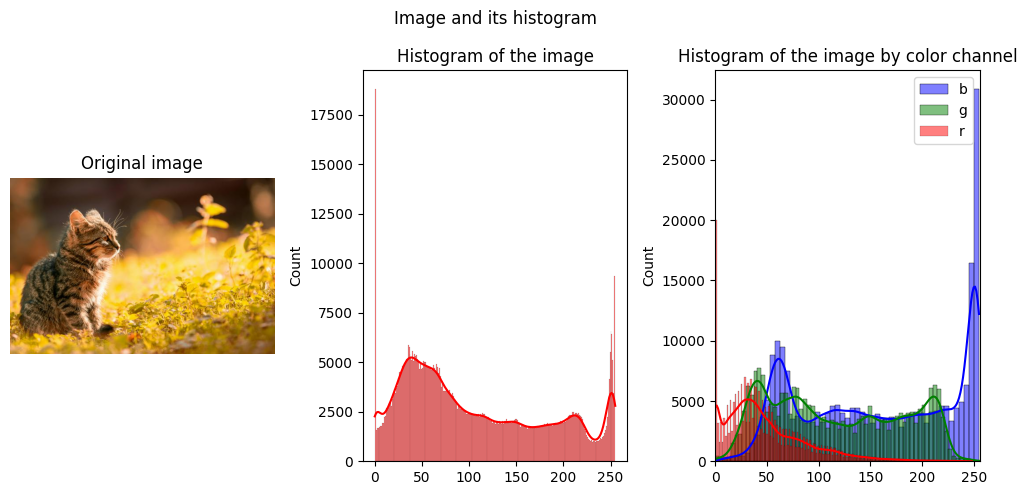

In [70]:
# Just for curiosity, how is histogram of the original image?
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(my_img)
axes[0].set_title('Original image')
axes[0].axis('off')

# Histogram of the image
sns.histplot(my_img.ravel(), bins=256, kde=True, color='red', ax=axes[1])
axes[1].set_title('Histogram of the image')

# Histogram by color channel
color = ('b','g','r')
for i, col in enumerate(color):
    sns.histplot(my_img[:,:,i].ravel(), kde=True, color=col, label=col, ax=axes[2])
    plt.xlim([0,256])

axes[2].legend()
axes[2].set_title('Histogram of the image by color channel')

fig.suptitle('Image and its histogram')
fig.tight_layout()
plt.show()

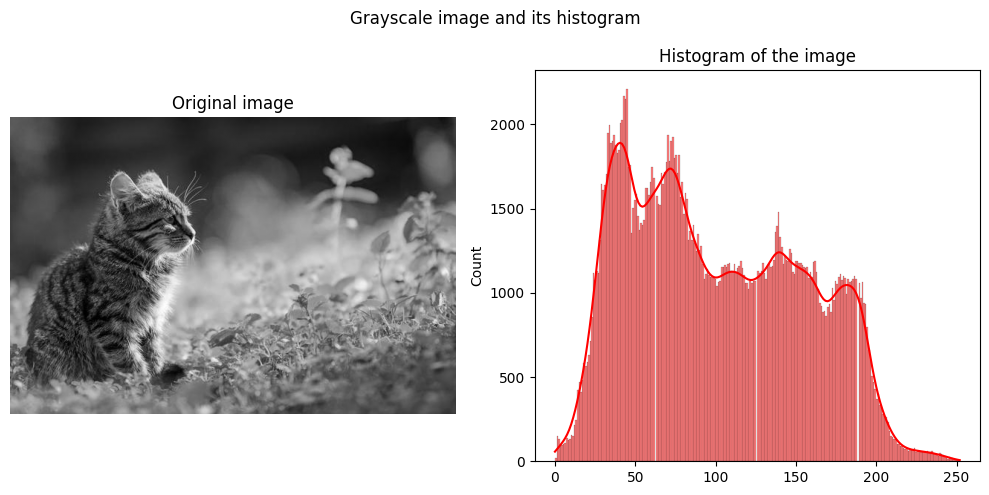

In [121]:
gray_image = cv2.cvtColor(my_img, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')

# Histogram of the image
sns.histplot(gray_image.ravel(), bins=256, kde=True, color='red', ax=axes[1])
axes[1].set_title('Histogram of the image')

fig.suptitle('Grayscale image and its histogram')
fig.tight_layout()
plt.show()

## TODO # 3: Find the contour of your own image

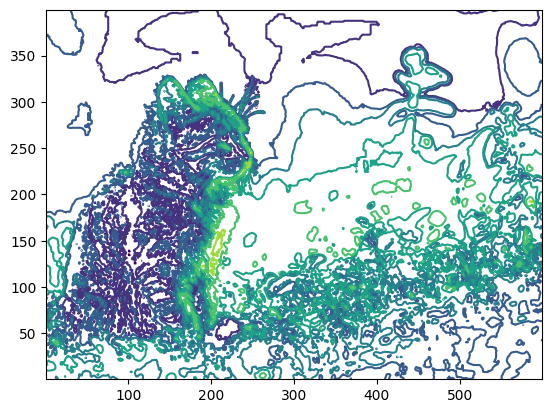

In [122]:
# Using matplotlib
plt.contour(gray_image, origin="image")
plt.show()

## TODO #4:  Try some mathematical operations on your image

In [123]:
TRANSFORMATIONS = {
    "Original": lambda img, **kwargs: img,
    "Negative": lambda img, **kwargs: 255 - img,
    "Logarithmic": lambda img, **kwargs: kwargs["c_log"] * np.log(1 + img),
    "Gamma": lambda img, **kwargs: kwargs["c_gamma"] * np.power(img, kwargs["gamma"])
}

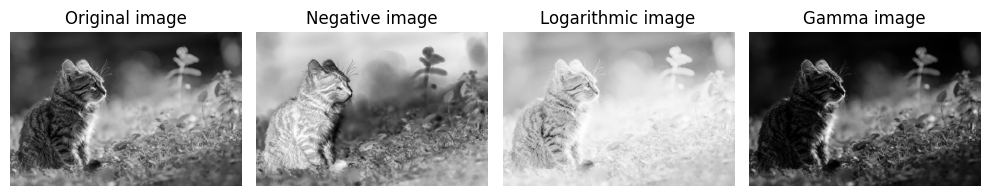

In [124]:
fig, axes = plt.subplots(1, 4, figsize=(10, 6))

for transformation, ax in zip(TRANSFORMATIONS.keys(), axes.flatten()):
    kwargs = {
        "c_log": 0.1,
        "c_gamma": 1,
        "gamma": 1.95,  # En este caso, gamma >= 2 provoca una imagen no entendible
    }
    ax.imshow(TRANSFORMATIONS[transformation](gray_image, **kwargs), cmap="gray")
    ax.set_title(f"{transformation} image")
    ax.axis("OFF")

fig.tight_layout()
plt.show()

## TODO #5:  Other warping

1. Choose a different set of source and destination coordinates to achieve a different perspective warp.  
2. What happens when the destination points are moved closer together or further apart?  

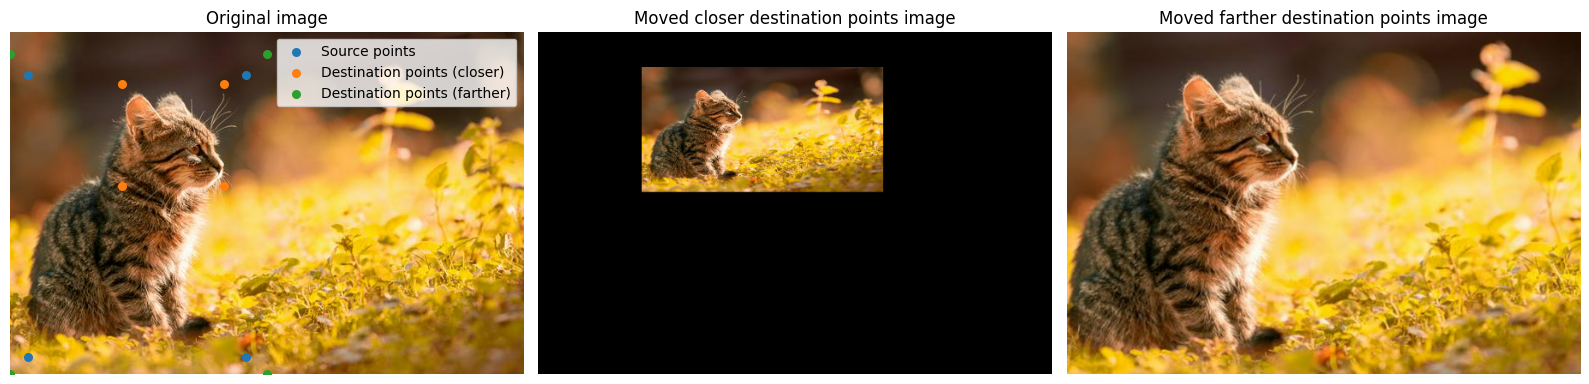

In [192]:
# my_img_rgb = cv2.cvtColor(my_img, cv2.COLOR_BGR2RGB)

src_pts = np.array([
    [20, 50],  # Top-left
    [275, 50],  # Top-right
    [20, 380],  # Bottom-left
    [275, 380]  # Bottom-right
], dtype=np.float32)  # Sí o sí debe ser float32

dst_pts1 = np.array([
    [130, 60],  # Top-left
    [250, 60],  # Top-right
    [130, 180],  # Bottom-left
    [250, 180]  # Bottom-right
], dtype=np.float32)

dst_pts2 = np.array([
    [0, 25],  # Top-left
    [300, 25],  # Top-right
    [0, 399],  # Bottom-left
    [300, 399]  # Bottom-right
], dtype=np.float32)

width, height = my_img.shape[0], my_img.shape[1]

perspective1 = cv2.getPerspectiveTransform(src_pts, dst_pts1)
warped_img1 = cv2.warpPerspective(my_img, perspective1, (height, width))

perspective2 = cv2.getPerspectiveTransform(src_pts, dst_pts2)
warped_img2 = cv2.warpPerspective(my_img, perspective2, (height, width))

fig, axes = plt.subplots(1, 3, figsize=(16, 9))

# Original image
axes[0].imshow(my_img)
axes[0].scatter(src_pts[:, 0], src_pts[:, 1], s=30, label="Source points")
axes[0].scatter(dst_pts1[:, 0], dst_pts1[:, 1], s=30, label="Destination points (closer)")
axes[0].scatter(dst_pts2[:, 0], dst_pts2[:, 1], s=30, label="Destination points (farther)")
axes[0].set_title('Original image')
axes[0].axis("off")
axes[0].legend()

# Closer
axes[1].imshow(warped_img1)
axes[1].set_title('Moved closer destination points image')
axes[1].axis("off")

# Farther
axes[2].imshow(warped_img2)
axes[2].set_title('Moved farther destination points image')
axes[2].axis("off")

fig.tight_layout()
plt.show()

## OPTIONAL

Feel free to load other images, modify them, explore other image processing functions available in OpenCV.

### Thresholds

Okay, se entiende a simple vista cómo es el funcionamiento de algunos umbrales, aunque me parece curioso OTSU y TRIANGLE, pues parecen hacer lo mismo, entonces no les veo mucho el sentido. Ahora, menos entiendo el funcionamiento de MASK, si quisiera todo negro, solo utilizo `np.zeros()` y ya. Pero bueno, en general, se entiende qué hacen los más "importantes".

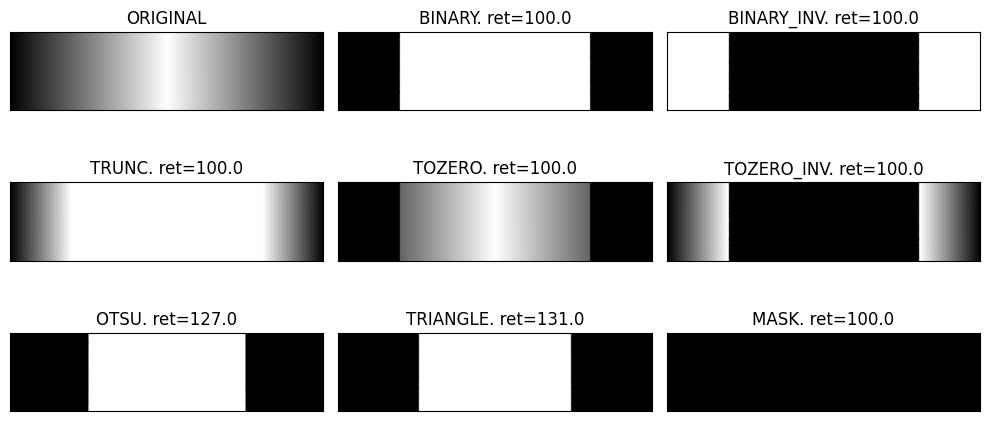

In [105]:
fig, axes = plt.subplots(3, 3, figsize=(10, 5))

test_image = cv2.imread("./images/gradient.png", cv2.IMREAD_GRAYSCALE)
test_image = np.concatenate([test_image, np.flip(test_image, axis=1)], axis=1)

TMP = {
    "BINARY": cv2.THRESH_BINARY,
    "BINARY_INV": cv2.THRESH_BINARY_INV,
    "TRUNC": cv2.THRESH_TRUNC,
    "TOZERO": cv2.THRESH_TOZERO,
    "TOZERO_INV": cv2.THRESH_TOZERO_INV,
    "OTSU": cv2.THRESH_OTSU,
    "TRIANGLE": cv2.THRESH_TRIANGLE,
    "MASK": cv2.THRESH_MASK,
    **{str(i): i for i in range(0, 256)}
}

titles = ["ORIGINAL", "BINARY", "BINARY_INV", "TRUNC", "TOZERO",
          "TOZERO_INV", "OTSU", "TRIANGLE", "MASK"]
for title, ax in zip(titles, axes.flatten()):
    ax.set(xticks=[], yticks=[])
    if title == "ORIGINAL":
        ax.imshow(test_image, cmap='gray')
        ax.set_title(title)
        continue

    ret, thresh = cv2.threshold(test_image, 100, 255, TMP[title])
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f"{title}. {ret=}")

fig.tight_layout()
plt.show()

### Contours

Visto muy por encima, parece tener resultados similares, por lo que, ya es necesario buscar en la documentación qué hace cada una de esas variables

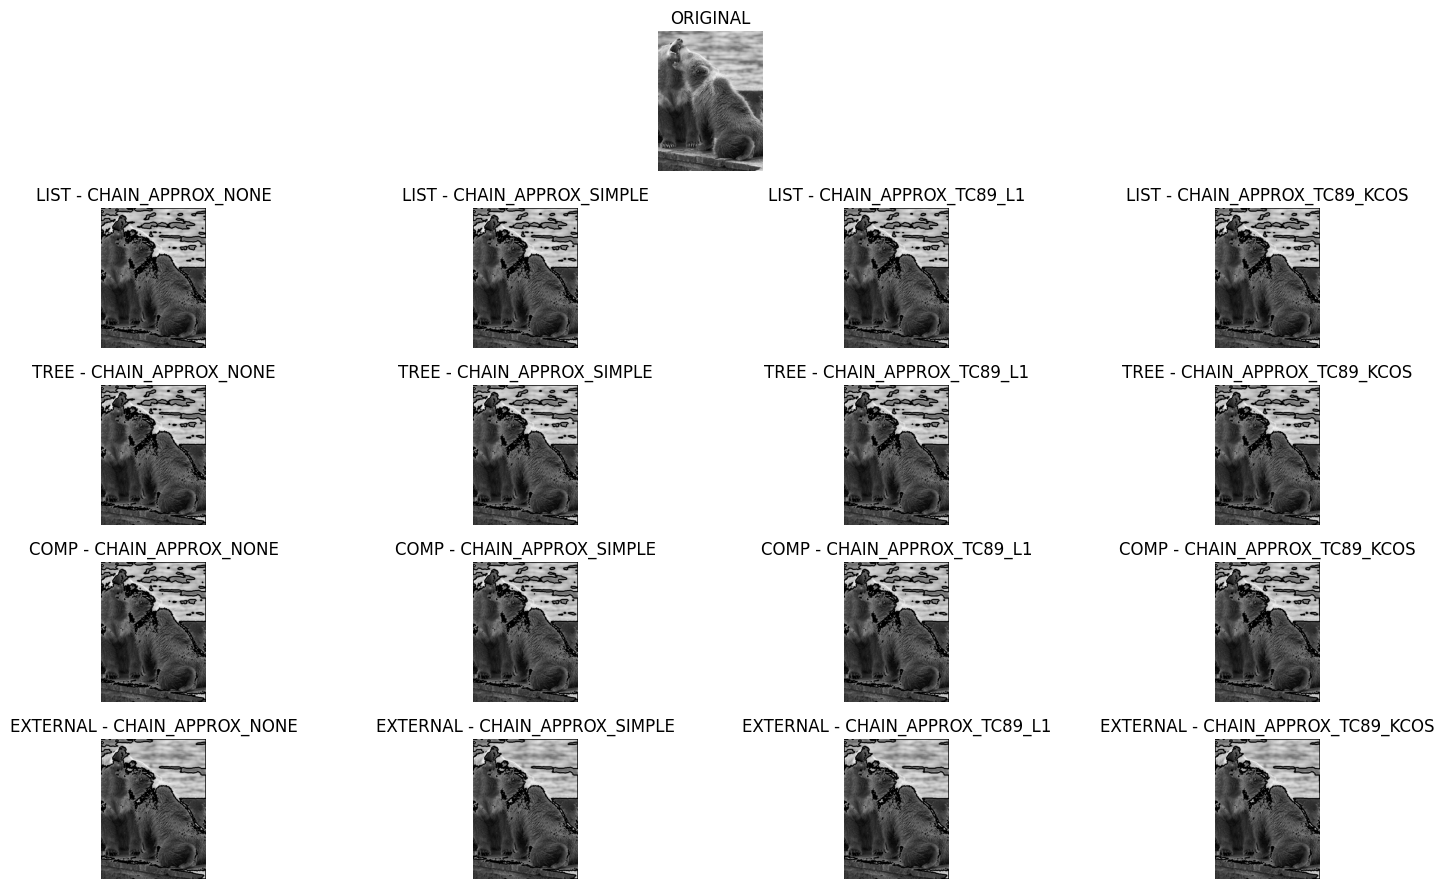

In [110]:
url = "https://placebear.com/450/600"
image = io.imread(url)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

TMP_RETR = {
    "LIST": cv2.RETR_LIST,
    "TREE": cv2.RETR_TREE,
    "COMP": cv2.RETR_CCOMP,
    "EXTERNAL": cv2.RETR_EXTERNAL
}

TMP_CHAIN = {
    "CHAIN_APPROX_NONE": cv2.CHAIN_APPROX_NONE,
    "CHAIN_APPROX_SIMPLE": cv2.CHAIN_APPROX_SIMPLE,
    "CHAIN_APPROX_TC89_L1": cv2.CHAIN_APPROX_TC89_L1,
    "CHAIN_APPROX_TC89_KCOS": cv2.CHAIN_APPROX_TC89_KCOS
}

fig, axes = plt.subplots(5, 4, figsize=(15, 9))

# Make the first row bigger and exclusive for original image
gs = axes[0, 3].get_gridspec()
for ax in axes[0, :]:
    ax.remove()

axbig = fig.add_subplot(gs[0, :])
axbig.imshow(image, cmap="gray")
axbig.set_title("ORIGINAL")
axbig.axis("off")

# Plot the rest of the images
for i, retr in enumerate(TMP_RETR.keys()):
    for j, chain in enumerate(TMP_CHAIN.keys()):
        # Just in case image is being modified (yes, it is)
        image = io.imread(url)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        ret, thresh = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)
        contours, hierarchy = cv2.findContours(thresh, TMP_RETR[retr], TMP_CHAIN[chain])
        cv2.drawContours(image, contours, -1, (0, 255, 0), 3)
        axes[i+1, j].imshow(image, cmap="gray")
        axes[i+1, j].set_title(f"{retr} - {chain}")
        axes[i+1, j].axis("off")

fig.tight_layout()
plt.show()